**EDA (Exploratory Data Analysis)**

1.   Imports

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

2.   Chargement du dataset

In [ ]:
url = "https://raw.githubusercontent.com/Nathal97/EXAMEN-ML/main/back/csv/dataset.csv"
df = pd.read_csv(url)


3.   Inspection de base

In [ ]:
print(f"Dimensions      : {df.shape[0]} lignes × {df.shape[1]} colonnes")
print(f"Colonnes        : {list(df.columns)}")
print(f"Valeurs manquantes: {df.isnull().sum().sum()}")
print(f"Cinq (5) premières lignes :")
display(df.head())


Dimensions      : 2739 lignes × 20 colonnes
Colonnes        : ['c0_x', 'c1_x', 'c2_x', 'c3_x', 'c4_x', 'c5_x', 'c6_x', 'c7_x', 'c8_x', 'c0_o', 'c1_o', 'c2_o', 'c3_o', 'c4_o', 'c5_o', 'c6_o', 'c7_o', 'c8_o', 'x_wins', 'is_draw']
Valeurs manquantes: 0
Cinq (5) premières lignes :


,c0_x,c1_x,c2_x,c3_x,c4_x,c5_x,c6_x,c7_x,c8_x,c0_o,c1_o,c2_o,c3_o,c4_o,c5_o,c6_o,c7_o,c8_o,x_wins,is_draw
0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1
1,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0
2,1,0,1,0,0,0,0,0,0,0,1,0,1,0,0,0,0,0,1,0
3,1,0,1,0,1,0,0,0,0,0,1,0,1,0,1,0,0,0,1,0
4,1,0,1,0,1,0,0,1,0,0,1,0,1,0,1,1,0,0,1,0


**Analyse des distributions**


Analyse de x_wins:


,Nombre,Pourcentage (%)
x_wins,,
1,1830,66.812705
0,909,33.187295


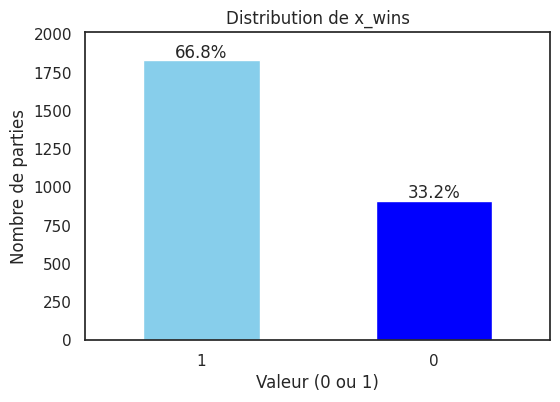


Interpretation :
Le dataset est DÉSÉQUILIBRÉ
Métrique privilégiée : F1-Score

Analyse de is_draw:


,Nombre,Pourcentage (%)
is_draw,,
0,2298,83.899233
1,441,16.100767


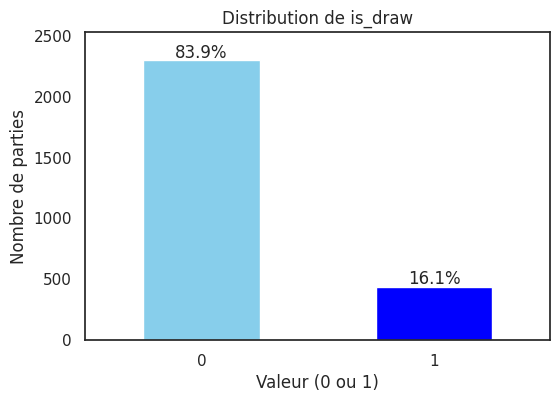


Interpretation :
Le dataset est DÉSÉQUILIBRÉ
Métrique privilégiée : F1-Score


In [ ]:
distributions = ['x_wins', 'is_draw']

for col in distributions:
    print(f"\nAnalyse de {col}:")
    counts = df[col].value_counts()
    percent = df[col].value_counts(normalize=True) * 100

    stats = pd.DataFrame({'Nombre': counts, 'Pourcentage (%)': percent})
    display(stats)

    plt.figure(figsize=(6, 4))
    ax = counts.plot(kind='bar', color=['skyblue', 'blue'])
    for i, p in enumerate(percent):
        ax.text(i, counts.iloc[i] + (counts.max() * 0.01), f'{p:.1f}%',
                ha='center')
    plt.title(f'Distribution de {col}')
    plt.xlabel('Valeur (0 ou 1)')
    plt.ylabel('Nombre de parties')
    plt.xticks(rotation=0)
    plt.ylim(0, counts.max() * 1.1)
    plt.show()

    ratio = counts.min() / counts.max()

    print(f"\nInterpretation :")
    if ratio < 0.5:
        print(f"Le dataset est DÉSÉQUILIBRÉ")
        print("Métrique privilégiée : F1-Score")
    else:
        print(f"Le dataset est relativement ÉQUILIBRÉ")
        print("Métrique privilégiée : Accuracy.")

La case la plus occupée par X

In [ ]:
victories_x = df[df['x_wins'] == 1]
cols_x = [f'c{i}_x' for i in range(9)]
occurences_par_case = victories_x[cols_x].sum()
display(occurences_par_case)
case_max = occurences_par_case.idxmax()
valeur_max = occurences_par_case.max()
print(f"La case la plus occupée par X lorsqu'il gagne est : {case_max} ({valeur_max} fois)")

,0
c0_x,569
c1_x,521
c2_x,569
c3_x,521
c4_x,592
c5_x,521
c6_x,569
c7_x,521
c8_x,569


La case la plus occupée par X lorsqu'il gagne est : c4_x (592 fois)


Heatmap

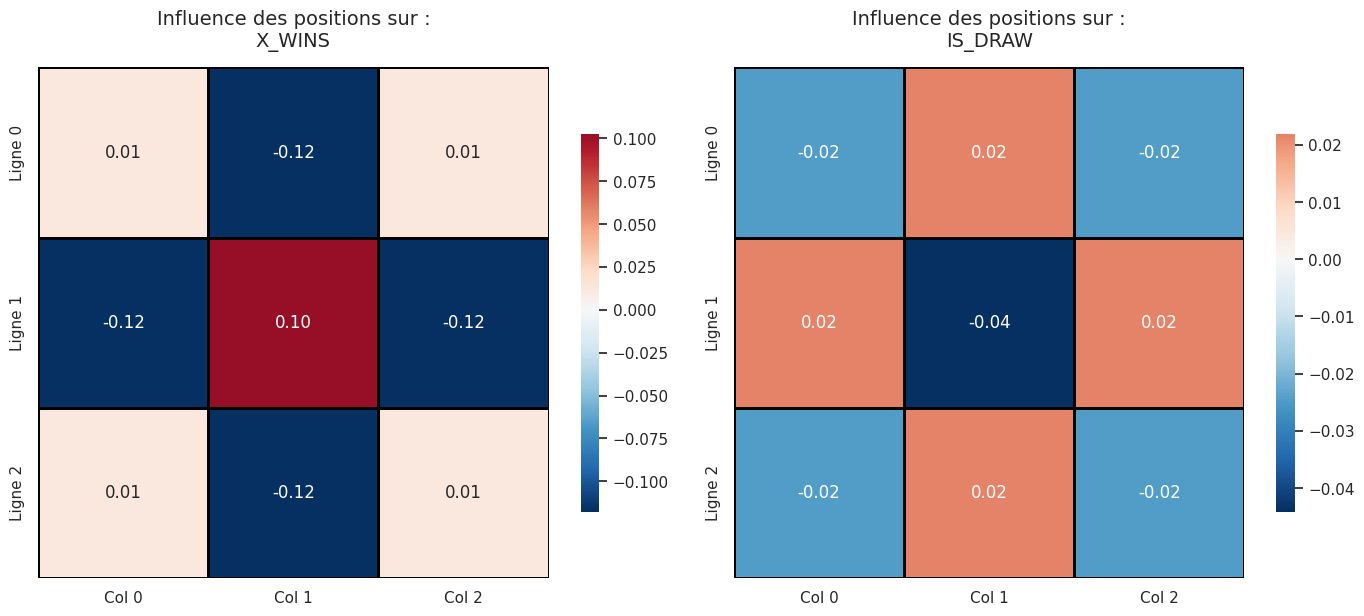

In [ ]:
distributions = ['x_wins', 'is_draw']

features_x = [f'c{i}_x' for i in range(9)]

plt.figure(figsize=(14, 6))


for i, cible in enumerate(distributions):

    corr_vector = df[features_x].corrwith(df[cible])

    corr_matrix = corr_vector.values.reshape(3, 3)

    plt.subplot(1, 2, i+1)
    sns.heatmap(corr_matrix,
                annot=True,
                fmt=".2f",
                cmap="RdBu_r",
                center=0,
                square=True,
                linewidths=2,
                linecolor='black',
                cbar_kws={"shrink": .7},
                xticklabels=['Col 0', 'Col 1', 'Col 2'],
                yticklabels=['Ligne 0', 'Ligne 1', 'Ligne 2'])

    plt.title(f'Influence des positions sur :\n{cible.upper()}', fontsize=14, pad=15)

plt.tight_layout()
plt.show()